# Module 10 Lab - Unsupervised Learning

**Objective:** To understand and apply two common **unsupervised learning** techniques: **K-Means Clustering** for finding groups in data and **Principal Component Analysis (PCA)** for dimensionality reduction.

**In this lab, you will write the code to perform clustering and PCA, and you will interpret the results.**

## Part 1: Supervised vs. Unsupervised Learning

So far, every model we have built has been a **supervised learning** model. This means we had **labeled data**—we had both the features (X) and the correct answer, or target (y). The goal was to learn a mapping from X to y.

In **unsupervised learning**, we only have the features (X). There is **no target variable**. The goal is to discover interesting structures or patterns hidden in the data on its own.

Two major types of unsupervised learning are:
*   **Clustering:** Automatically grouping similar data points together.
*   **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering

**Concept:** K-Means is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:
1.  Randomly placing `k` centroids (the center of a cluster) in the data.
2.  **Assignment Step:** Assigning each data point to its nearest centroid.
3.  **Update Step:** Moving each centroid to the average position of all the points assigned to it.
4.  Repeating steps 2 and 3 until the centroids stop moving.

**Problem:** We will use a synthetic dataset of customer spending habits to segment them into groups.

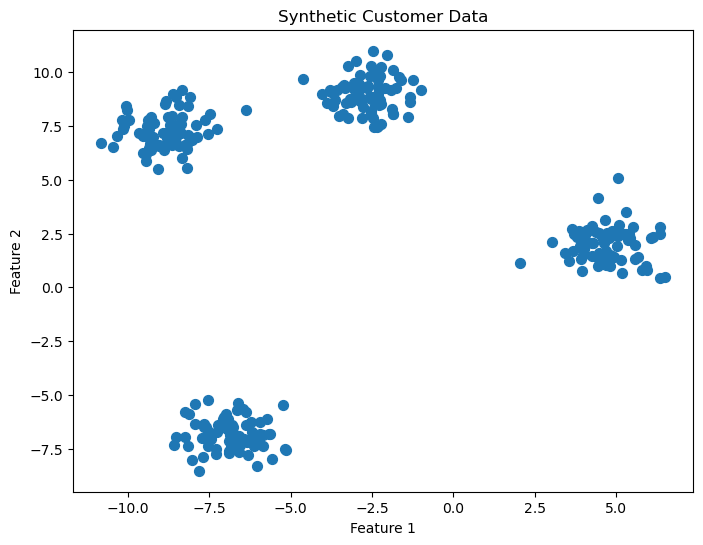

In [22]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)

**Concept:** How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.

**Your Task:** Calculate and plot the inertia for `k` values from 1 to 10.

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

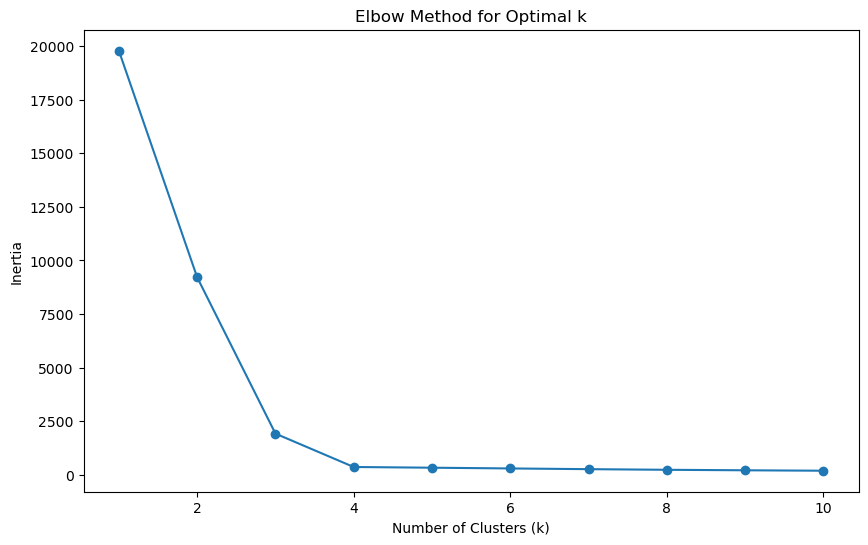

In [23]:
from sklearn.cluster import KMeans

# --- ENTER YOUR CODE HERE ---

# 1. Create an empty list to store the inertia values
# inertia = []
inertia = []

# 2. Loop through k values from 1 to 10
# for k in range(1, 11):
    # 3. Create and fit a KMeans model with `n_clusters=k`
    # kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # kmeans.fit(X)
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    # 4. Append the model's inertia_ to your list
    inertia.append(kmeans.inertia_)

# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

### Task 2: Perform K-Means Clustering and Visualize

From the elbow plot, it looks like `k=4` is the optimal number of clusters.

**Your Task:** Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


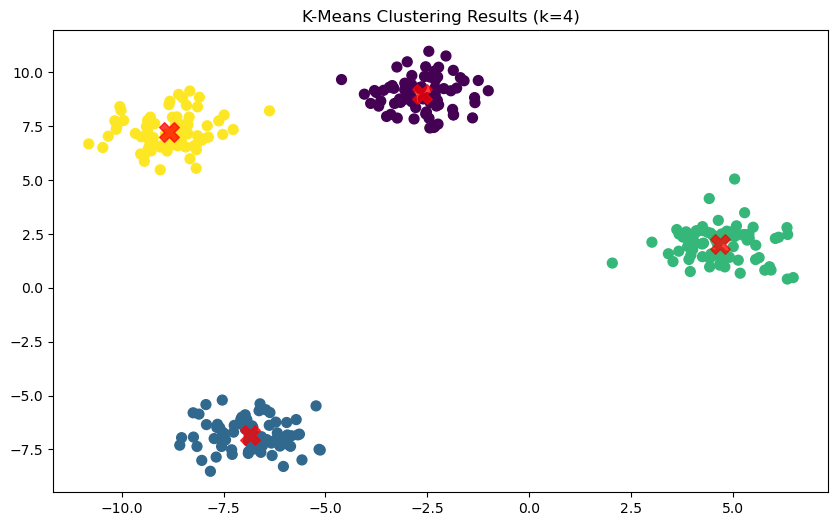

In [24]:
# --- ENTER YOUR CODE HERE ---

# 1. Create and fit a KMeans model with n_clusters=4
# kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
# kmeans.fit(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# 2. Get the cluster assignments for each data point
# labels = kmeans.labels_
labels = kmeans.labels_

# 3. Get the coordinates of the cluster centers
# centers = kmeans.cluster_centers_
centers = kmeans.cluster_centers_

# 4. Create a scatter plot of the data, colored by the labels
# plt.figure(figsize=(10, 6))
# plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
# plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X') # Plot the centers
# plt.title('K-Means Clustering Results (k=4)')
# plt.show()
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X') # Plot the centers
plt.title('K-Means Clustering Results (k=4)')
plt.show()

## Part 3: Principal Component Analysis (PCA)

**Concept:** PCA is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.

**Use Cases:**
*   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.
*   **Performance:** Speeding up model training by using fewer features.

**Problem:** We will use the Iris dataset, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset

**Your Task:** Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

Explained variance by component: [0.92461872 0.05306648]
Total variance explained by 2 components: 97.77%


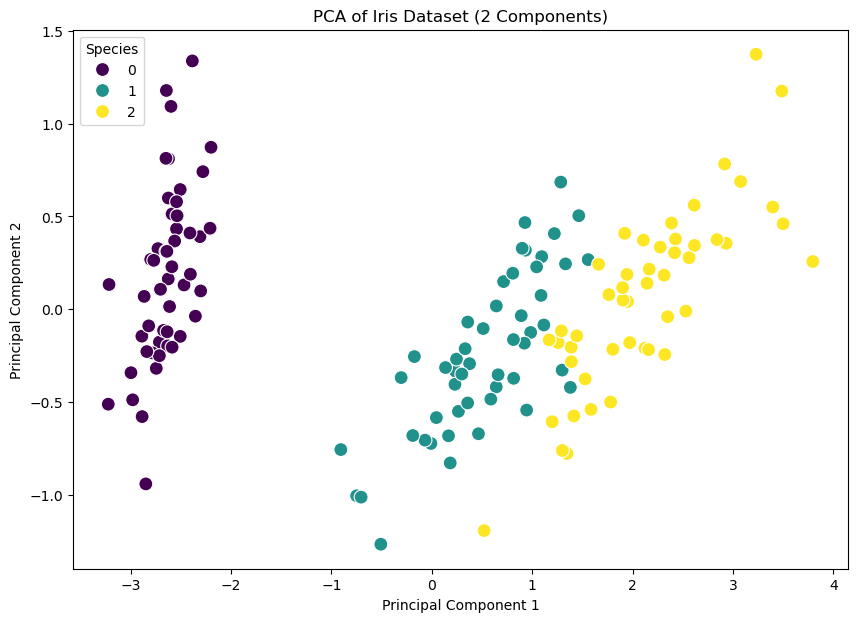

In [25]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import pandas as pd

# Load the data
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# --- ENTER YOUR CODE HERE ---

# 1. Create a PCA instance to reduce to 2 components
# pca = PCA(n_components=2)
pca = PCA(n_components=2)

# 2. Fit PCA to the data and transform it
# X_pca = pca.fit_transform(X_iris)
X_pca = pca.fit_transform(X_iris)

# 3. Print the explained variance ratio
# print(f"Explained variance by component: {pca.explained_variance_ratio_}")
# print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# 4. Create a DataFrame with the PCA results for plotting
# pca_df = pd.DataFrame(data=X_pca, columns=["Principal Component 1", "Principal Component 2"])
# pca_df["Species"] = y_iris
pca_df = pd.DataFrame(data=X_pca, columns=["Principal Component 1", "Principal Component 2"])
pca_df["Species"] = y_iris

# 5. Plot the results
# plt.figure(figsize=(10, 7))
# sns.scatterplot(x="Principal Component 1", y="Principal Component 2", hue="Species", data=pca_df, palette='viridis', s=100)
# plt.title('PCA of Iris Dataset (2 Components)')
# plt.show()
plt.figure(figsize=(10, 7))
sns.scatterplot(x="Principal Component 1", y="Principal Component 2", hue="Species", data=pca_df, palette='viridis', s=100)
plt.title('PCA of Iris Dataset (2 Components)')
plt.show()

## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

1.  **What is the fundamental difference between supervised and unsupervised learning?**
2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**
3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?**

**[ENTER YOUR ANSWERS HERE]**

1. Supervised learning uses labeled data while unsupervised learning tries to find patterns based off of the input data.
2. The largest k would create too many clusters, which would cause overfitting. The elbow point shows where adding more clusters gives us diminishing returns.
3. The original 4-dimensional Iris dataset is redundant. Since the Iris dataset with 2 dimensions variance is 97.77%, most of the information in the original can be represented almost as well with 2.